# Fig. 1d, 2e,  3d, and s7b

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import UnivariateSpline, make_interp_spline
from scipy.ndimage import uniform_filter1d


PANEL_FILE = Path("PanelResults") / "worker_day_panel.csv"
OUTPUT_DIR = Path("MainFigures")
SI_DIR = Path("SI_Figures")
CITY = "Harbin"
CUTOFF_DATE = "2025-10-15"
OVERLOAD_THRESHOLD = 41.62
MIN_BIN_COUNT_FOR_BAND = 100
MEAN_LINE_X_MIN = -35
MEAN_LINE_X_MAX = 5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SI_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
required_columns = {
    "Date",
    "Location",
    "WorkerClass",
    "Ta_min",
    "Workload",
    "On-dutyHour",
    "OrderCount"
}

df = pd.read_csv(PANEL_FILE, encoding="utf-8-sig")
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for column in ["Ta_min", "Workload", "On-dutyHour", "OrderCount"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

plot_data = df[
    (df["Location"] == CITY)
    & (df["Date"] <= pd.to_datetime(CUTOFF_DATE))
].copy()

EliteGroup_daily = plot_data[plot_data["WorkerClass"] == "Elite"].copy()
RegularGroup_daily = plot_data[plot_data["WorkerClass"] == "Regular"].copy()

print(f"Rows used for {CITY}: {len(plot_data)}")
print(plot_data["WorkerClass"].value_counts(dropna=False).to_string())


Rows used for Harbin: 17063
WorkerClass
Regular    9677
Elite      7386


In [3]:
sns.set_style("ticks")
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.linewidth": 2,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "lines.solid_capstyle": "round",
})


def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i + 2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)


COLORS = {
    "elite_fill": hex_to_rgba("#2181AE", 0.2),
    "regular_fill": hex_to_rgba("#000000", 0.05),
    "elite_line": "#2181AE",
    "regular_line": hex_to_rgba("#000000", 0.4),
    "point_face": "white",
    "point_edge_e": hex_to_rgba("#2181AE", 1.0),
    "point_edge_r": hex_to_rgba("#000000", 0.4),
    "elite_band_lo": hex_to_rgba("#2181AE", 1.0),
    "elite_band_hi": hex_to_rgba("#2181AE", 1.0),
    "regular_band_lo": hex_to_rgba("#000000", 0.4),
    "regular_band_hi": hex_to_rgba("#000000", 0.4),
}


In [4]:
def compute_percentile_band_smooth(x, y, bins=np.arange(-35, 6, 5), smooth_factor=0.05, min_bin_count=100):
    data = pd.DataFrame({"x": x, "y": y}).dropna()
    data["bin"] = pd.cut(data["x"], bins=bins, include_lowest=True, right=True)

    grouped = data.groupby("bin", observed=False)["y"]
    stats = pd.DataFrame({
        "count": grouped.count(),
        "mean": grouped.mean(),
        "p25": grouped.quantile(0.25),
        "p75": grouped.quantile(0.75),
    })

    idx = pd.IntervalIndex.from_breaks(bins, closed="right")
    stats = stats.reindex(idx)
    centers = 0.5 * (bins[:-1] + bins[1:])
    stats.index = centers

    valid = stats.dropna()
    valid = valid[valid["count"] >= min_bin_count]
    valid = valid[(valid.index >= -35) & (valid.index <= 5)]
    x_mean = valid.index.values
    y_mean = valid["mean"].values
    if len(valid) < 4:
        return x_mean, y_mean, valid["p25"].values, valid["p75"].values, x_mean, y_mean

    x_smooth = np.linspace(-35, 5, 200)

    # Mean: moving-average + UnivariateSpline (keeps publication smoothness)
    window = min(3, len(valid) // 2)
    mean_smoothed = uniform_filter1d(y_mean, size=window, mode="nearest")
    s_adj = smooth_factor * (5 / max(len(valid), 1))
    mean_spline = UnivariateSpline(x_mean, mean_smoothed, k=2, s=s_adj)
    mean_smooth = mean_spline(x_smooth)

    # Quantile boundaries: moving-average + UnivariateSpline
    low_smoothed = uniform_filter1d(valid["p25"].values, size=window, mode="nearest")
    high_smoothed = uniform_filter1d(valid["p75"].values, size=window, mode="nearest")
    spline_low = UnivariateSpline(valid.index, low_smoothed, k=2, s=s_adj)
    spline_high = UnivariateSpline(valid.index, high_smoothed, k=2, s=s_adj)
    low_smooth = spline_low(x_smooth)
    high_smooth = spline_high(x_smooth)
    low_smooth = np.minimum(low_smooth, mean_smooth - 0.1)
    high_smooth = np.maximum(high_smooth, mean_smooth + 0.1)

    mean_smooth[(x_smooth < MEAN_LINE_X_MIN) | (x_smooth > MEAN_LINE_X_MAX)] = np.nan
    return x_smooth, mean_smooth, low_smooth, high_smooth, x_mean, y_mean


def calc_overload_ratio(x, y, bins, threshold=40):
    data = pd.DataFrame({"Ta": x, "Workload": y}).dropna()
    data["bin"] = pd.cut(data["Ta"], bins=bins, include_lowest=True, right=True)
    ratio = data.groupby("bin", observed=True)["Workload"].apply(lambda values: (values > threshold).mean())
    idx = pd.IntervalIndex.from_breaks(bins, closed="right")
    ratio = ratio.reindex(idx, fill_value=0)
    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, ratio.values


def draw_band(ax, x, y, bins, smooth_factor=0.3, ylabel=""):
    x_e, y_e = EliteGroup_daily[x], EliteGroup_daily[y]
    x_r, y_r = RegularGroup_daily[x], RegularGroup_daily[y]

    xE, yE_mean_s, yE_l, yE_h, xE_c, yE_mean = compute_percentile_band_smooth(
        x_e, y_e, bins, smooth_factor=smooth_factor, min_bin_count=MIN_BIN_COUNT_FOR_BAND
    )
    xR, yR_mean_s, yR_l, yR_h, xR_c, yR_mean = compute_percentile_band_smooth(
        x_r, y_r, bins, smooth_factor=smooth_factor, min_bin_count=MIN_BIN_COUNT_FOR_BAND
    )

    ax.fill_between(xE, yE_l, yE_h, color=COLORS["elite_fill"], zorder=1)
    ax.fill_between(xR, yR_l, yR_h, color=COLORS["regular_fill"], zorder=1)
    ax.plot(xE, yE_l, color=COLORS["elite_band_lo"], lw=0.6)
    ax.plot(xE, yE_h, color=COLORS["elite_band_hi"], lw=0.6)
    ax.plot(xR, yR_l, color=COLORS["regular_band_lo"], lw=0.6)
    ax.plot(xR, yR_h, color=COLORS["regular_band_hi"], lw=0.6)
    ax.plot(xE, yE_mean_s, color=COLORS["elite_line"], lw=2.8, label="Elite", zorder=3)
    ax.plot(xR, yR_mean_s, color=COLORS["regular_line"], lw=2.8, label="Regular", zorder=3)
    elite_mean_mask = (xE_c >= MEAN_LINE_X_MIN) & (xE_c <= MEAN_LINE_X_MAX)
    regular_mean_mask = (xR_c >= MEAN_LINE_X_MIN) & (xR_c <= MEAN_LINE_X_MAX)
    ax.scatter(xE_c[elite_mean_mask], yE_mean[elite_mean_mask], facecolors=COLORS["point_face"], edgecolors=COLORS["point_edge_e"], s=60, linewidths=0.6, zorder=4)
    ax.scatter(xR_c[regular_mean_mask], yR_mean[regular_mean_mask], facecolors=COLORS["point_face"], edgecolors=COLORS["point_edge_r"], s=60, linewidths=0.6, zorder=4)
    ax.set_xlabel("Daily minimum temperature (°C)")
    ax.set_ylabel(ylabel)
    ax.invert_xaxis()
    return x_e, y_e, x_r, y_r


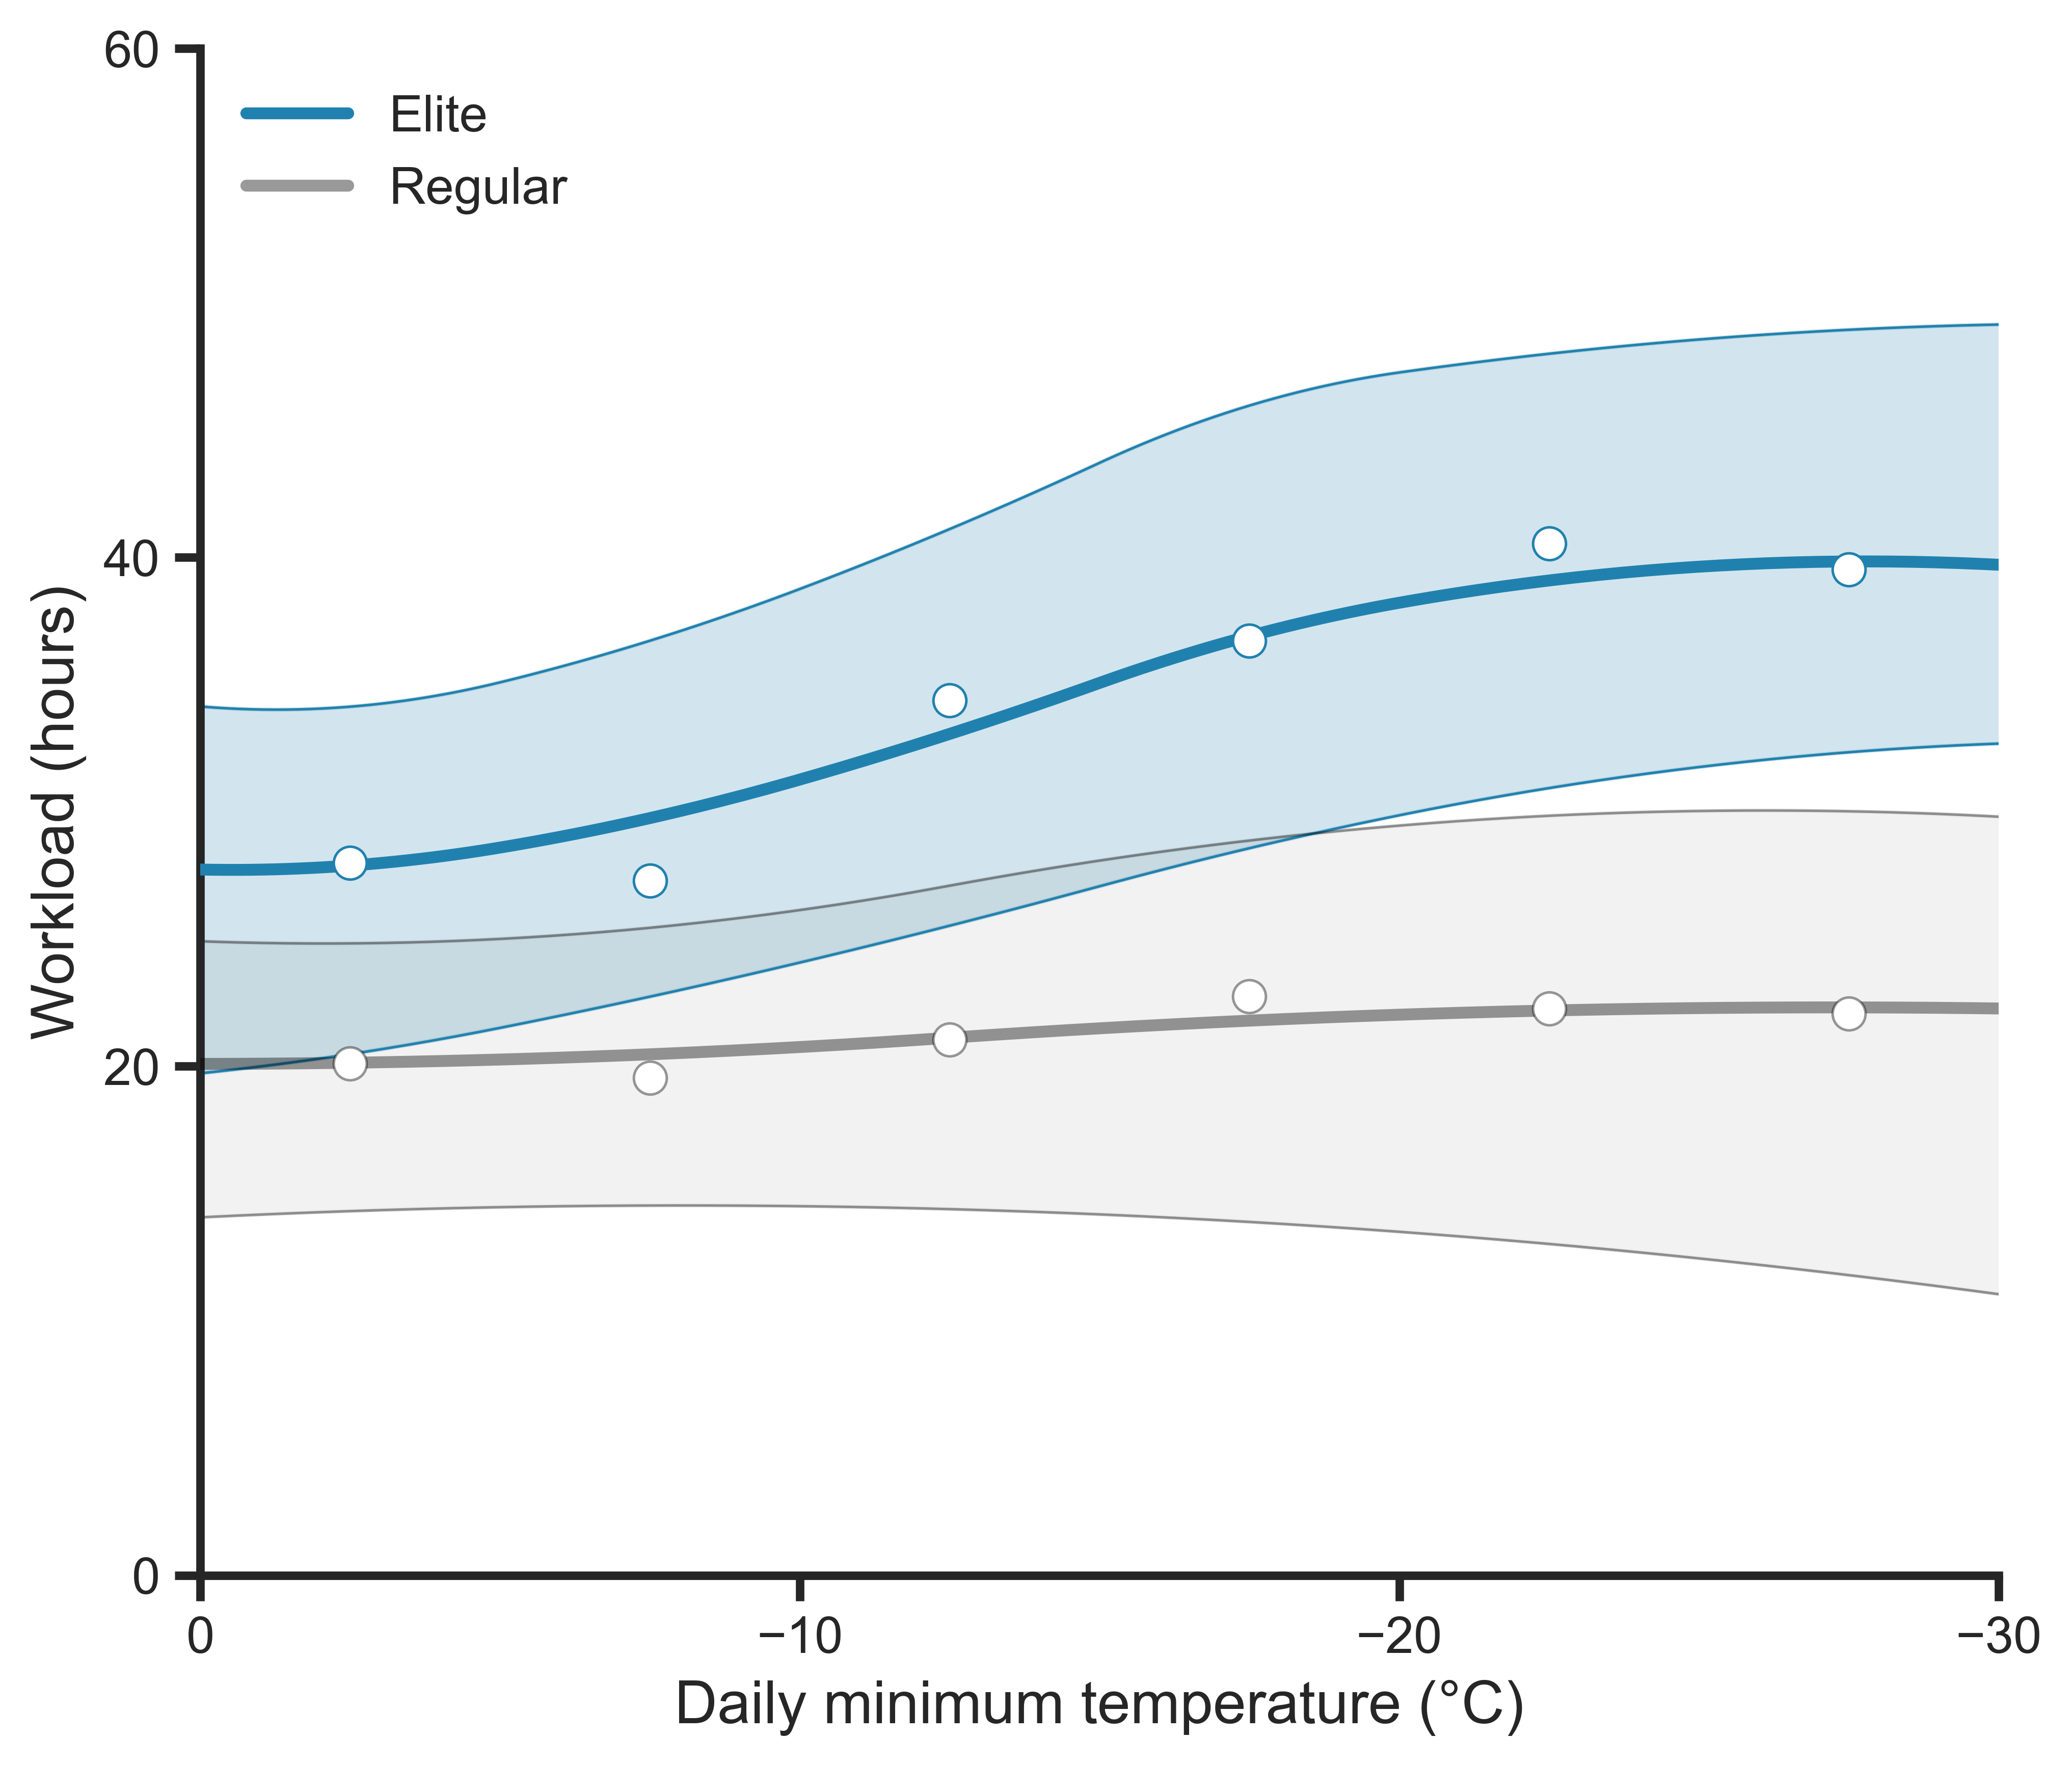

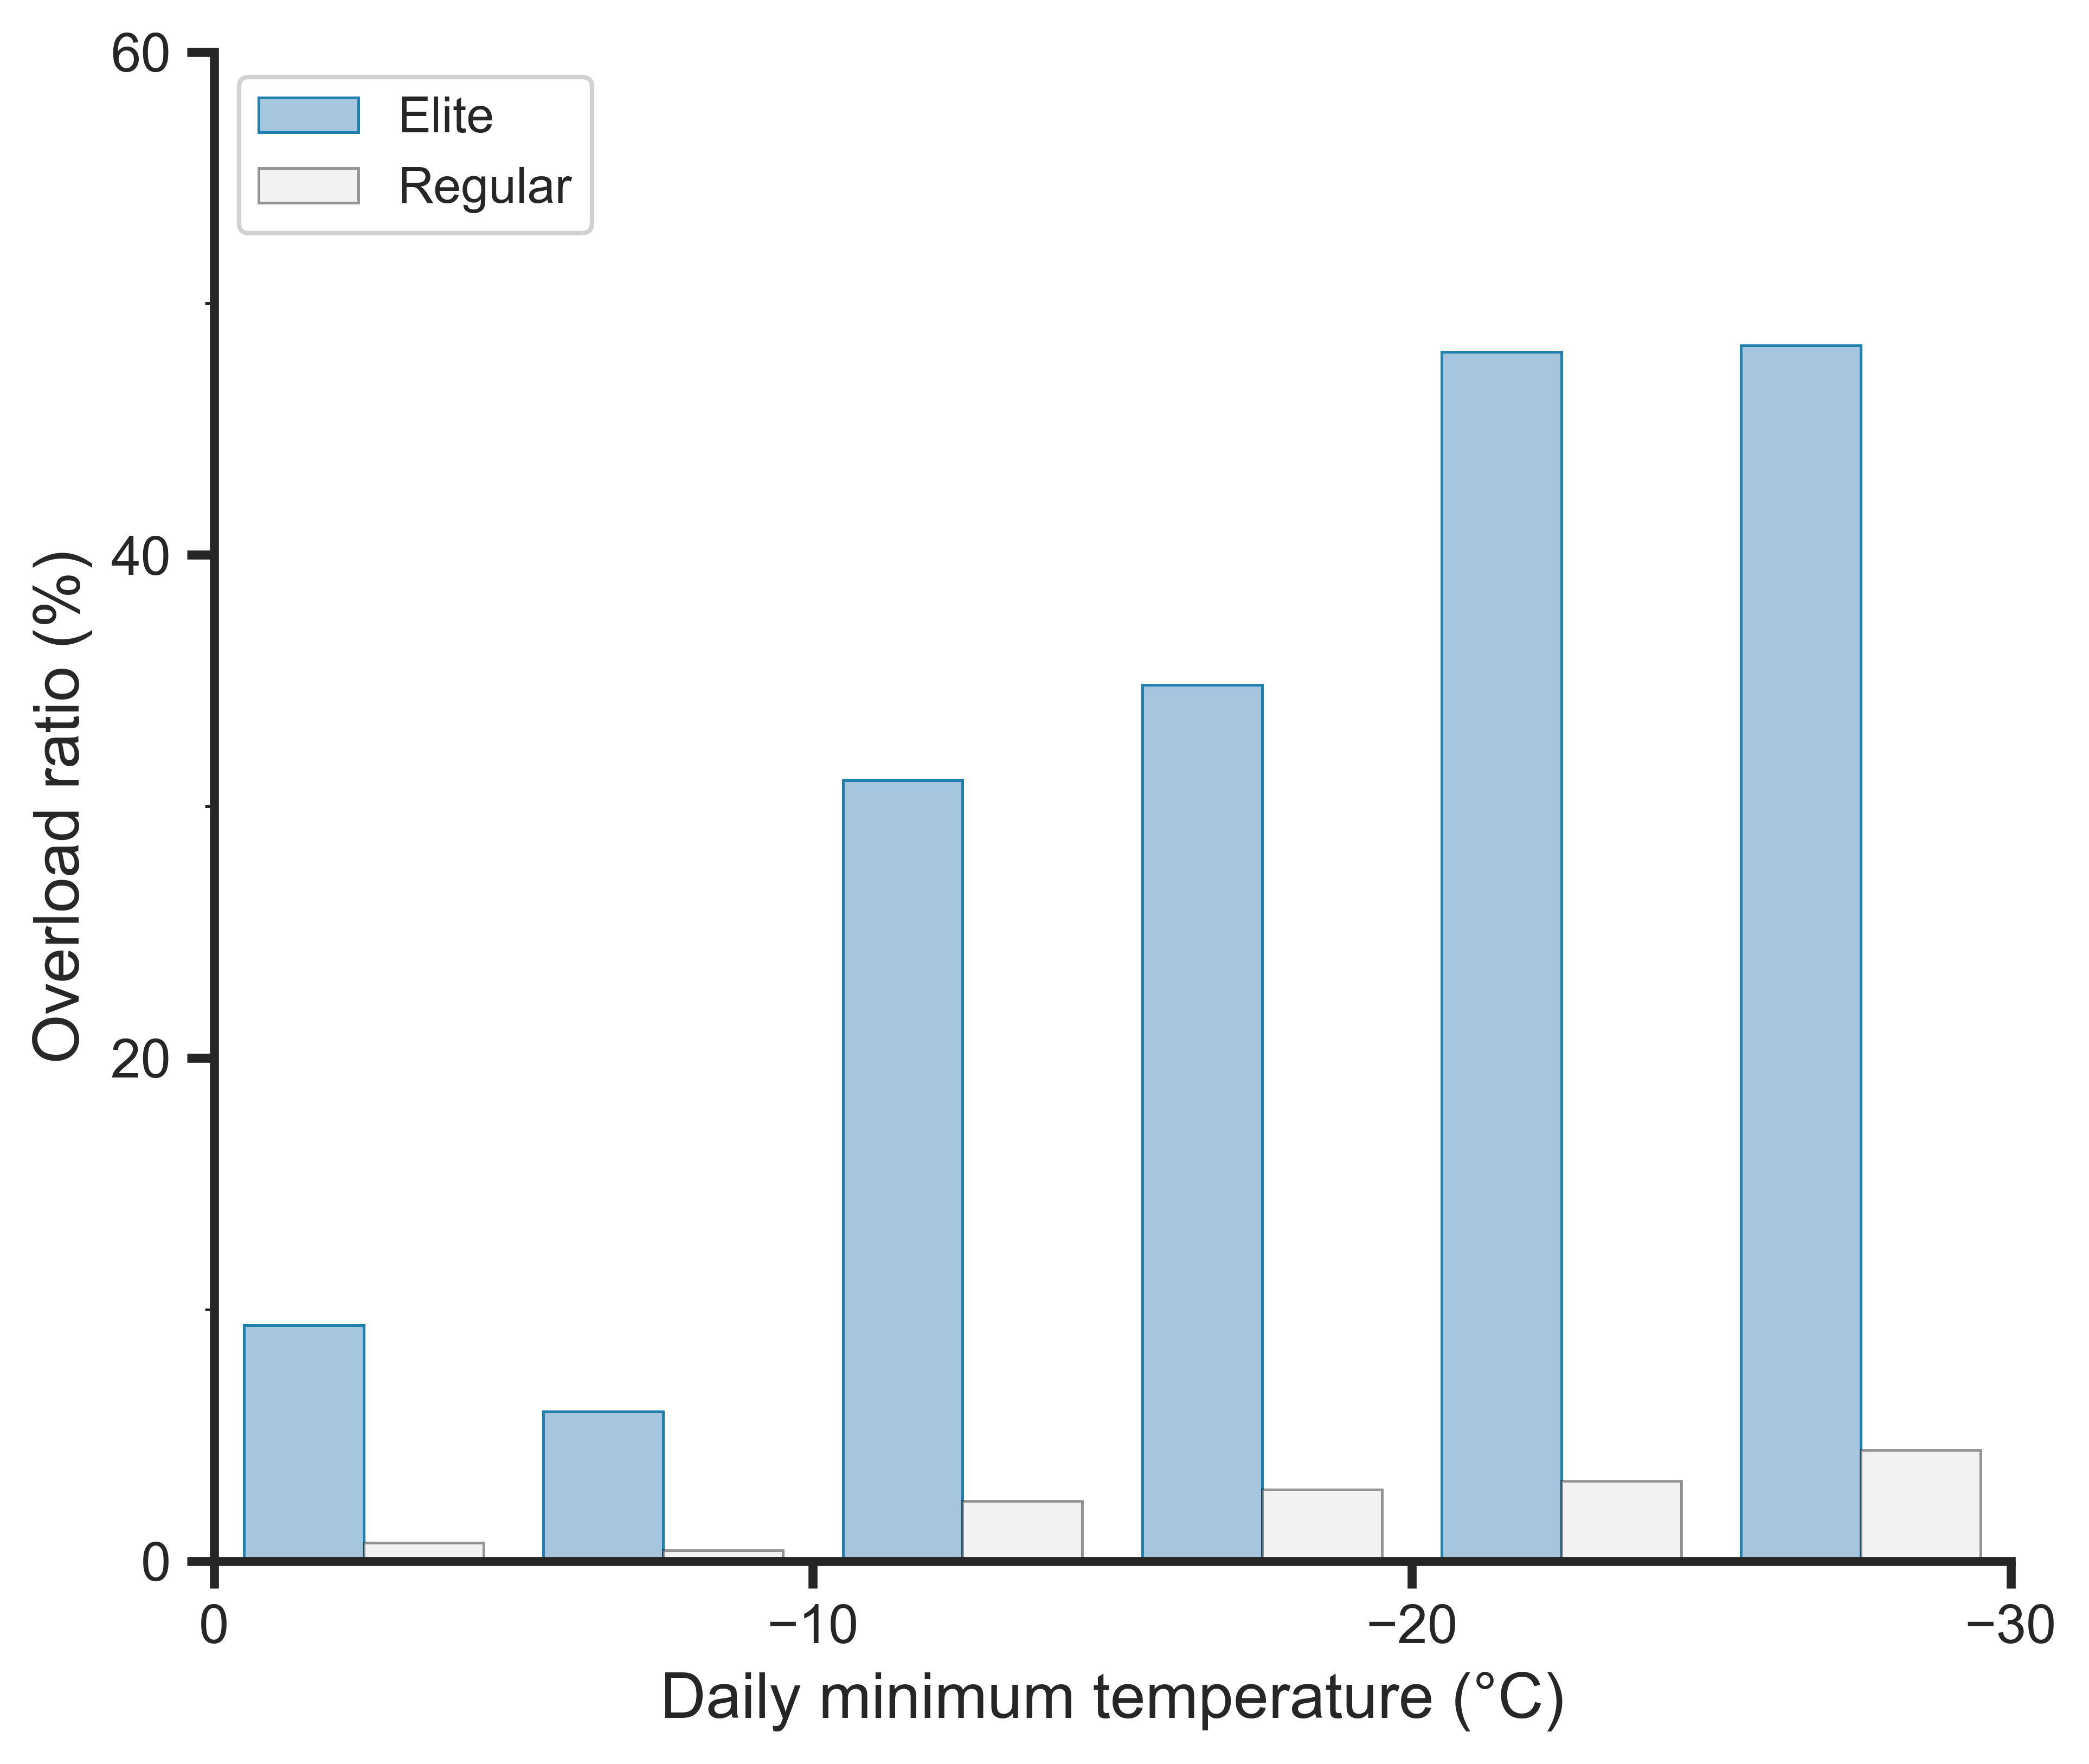

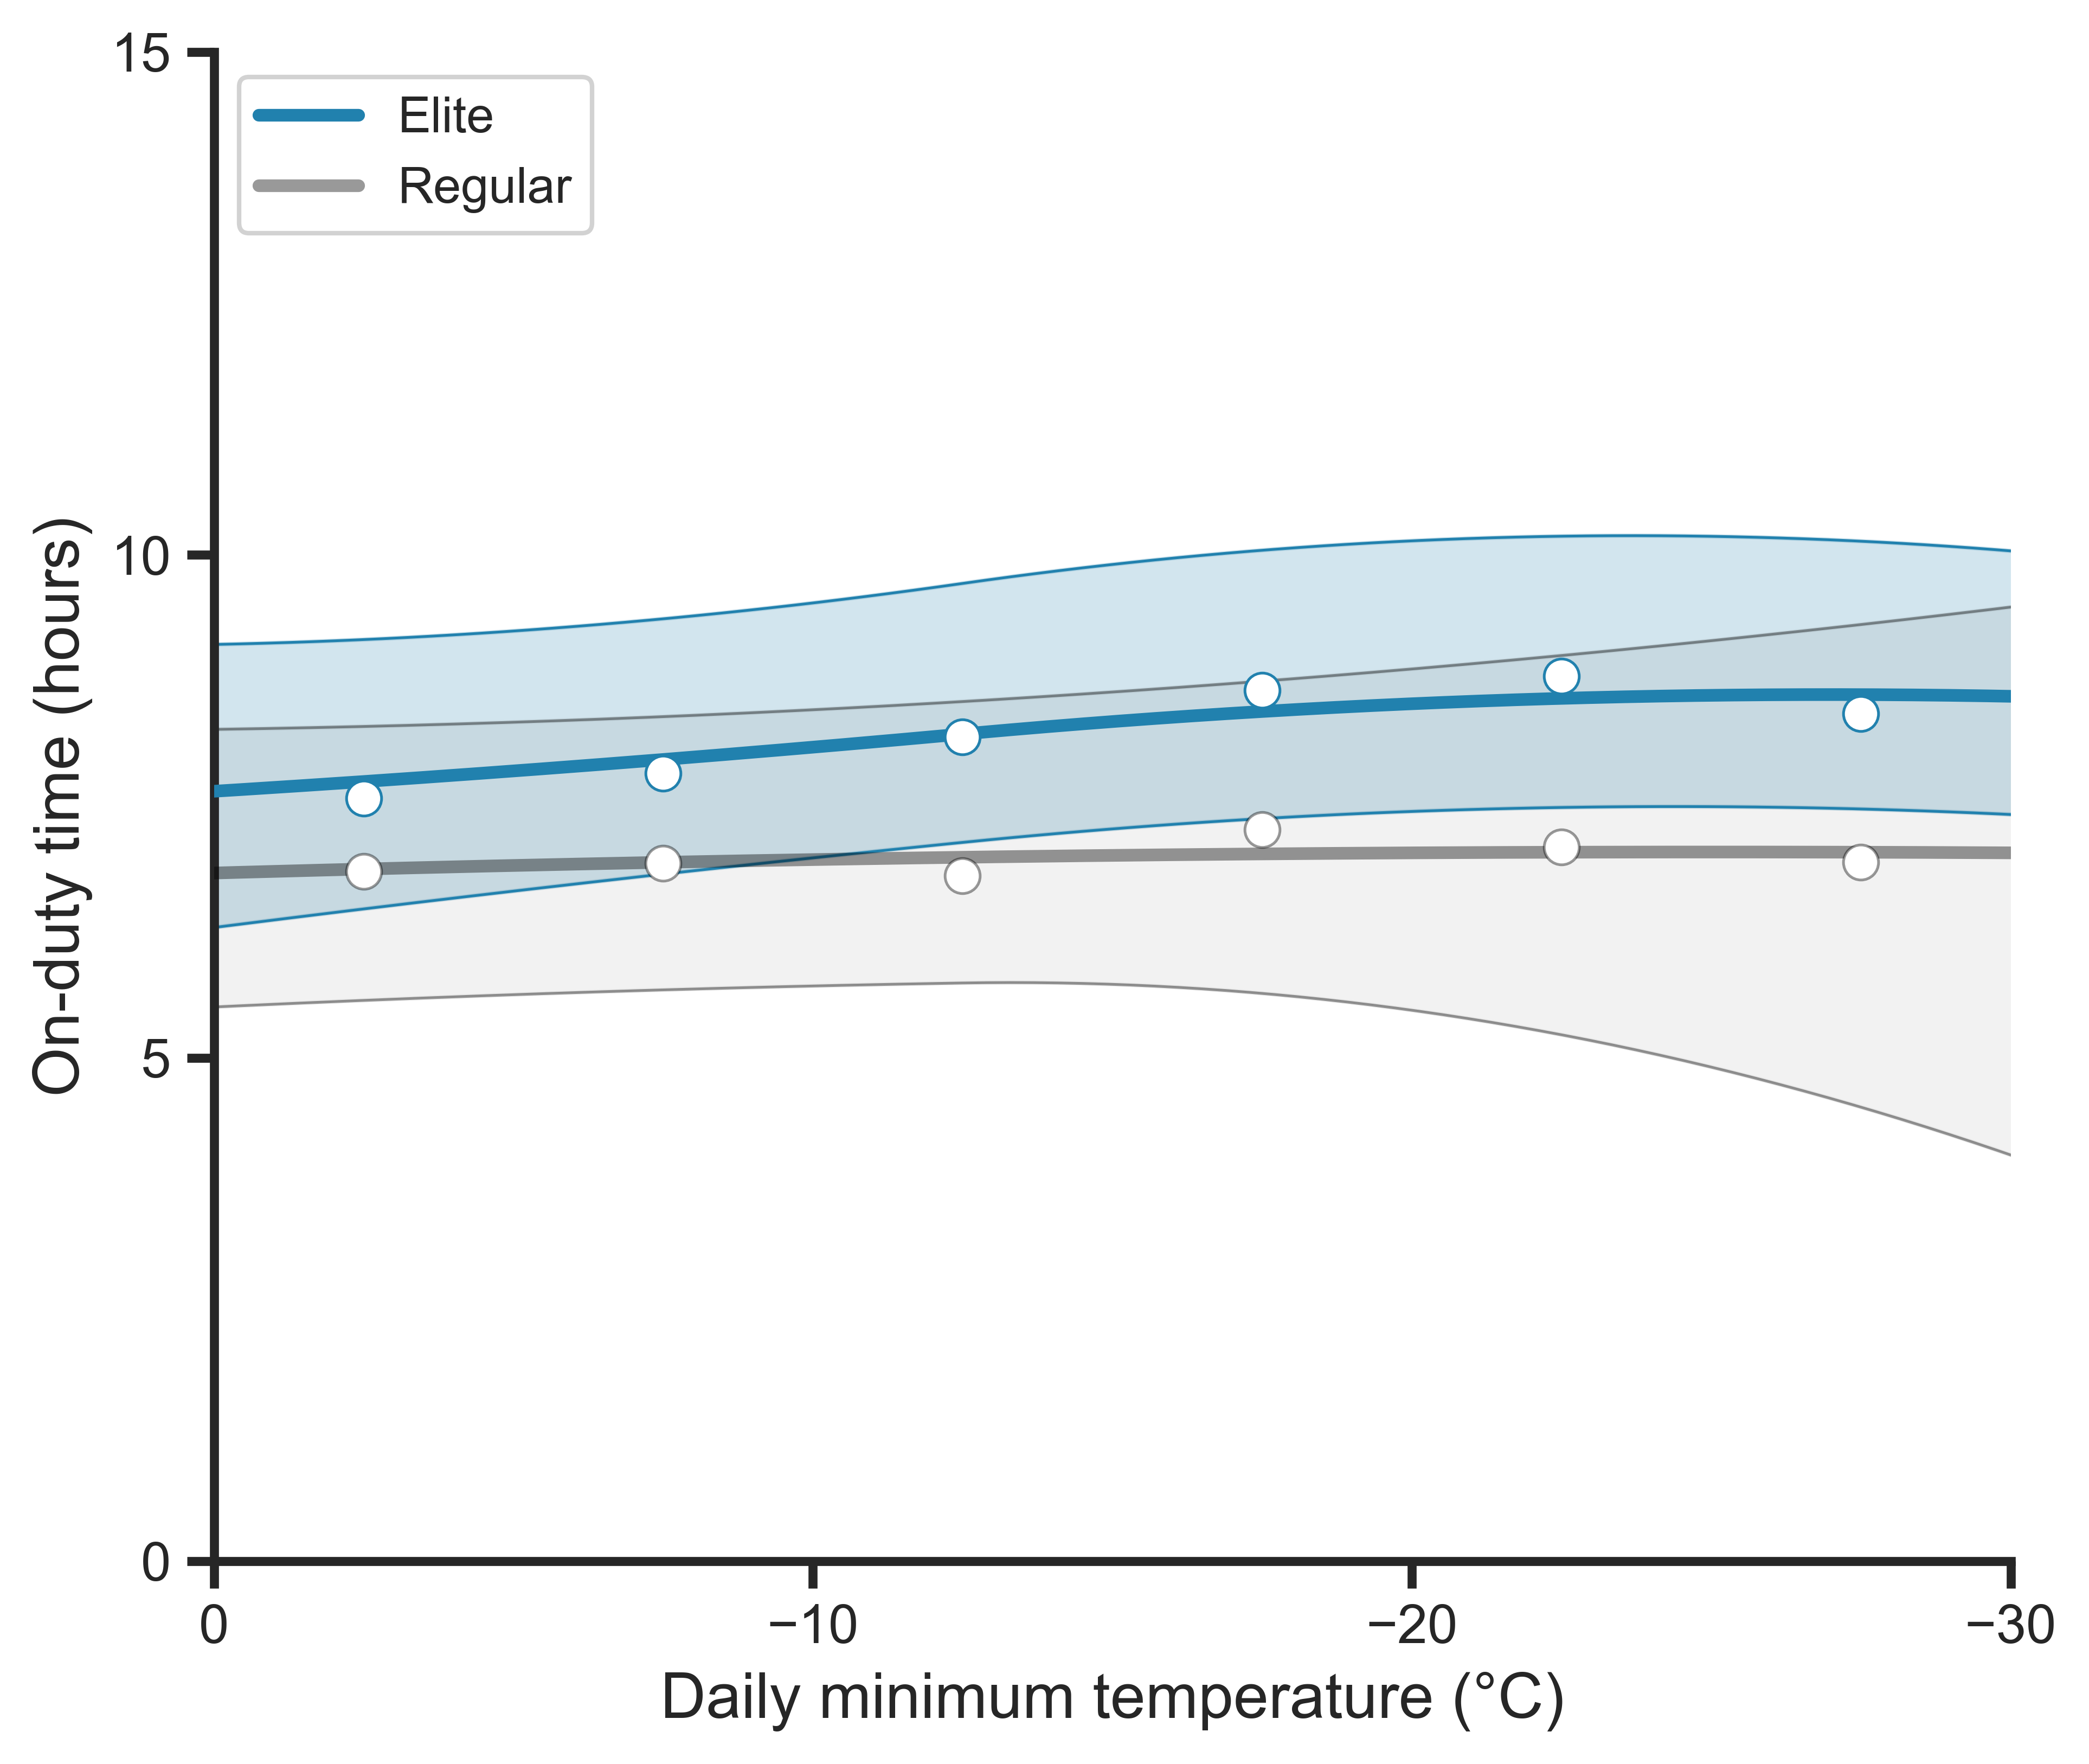

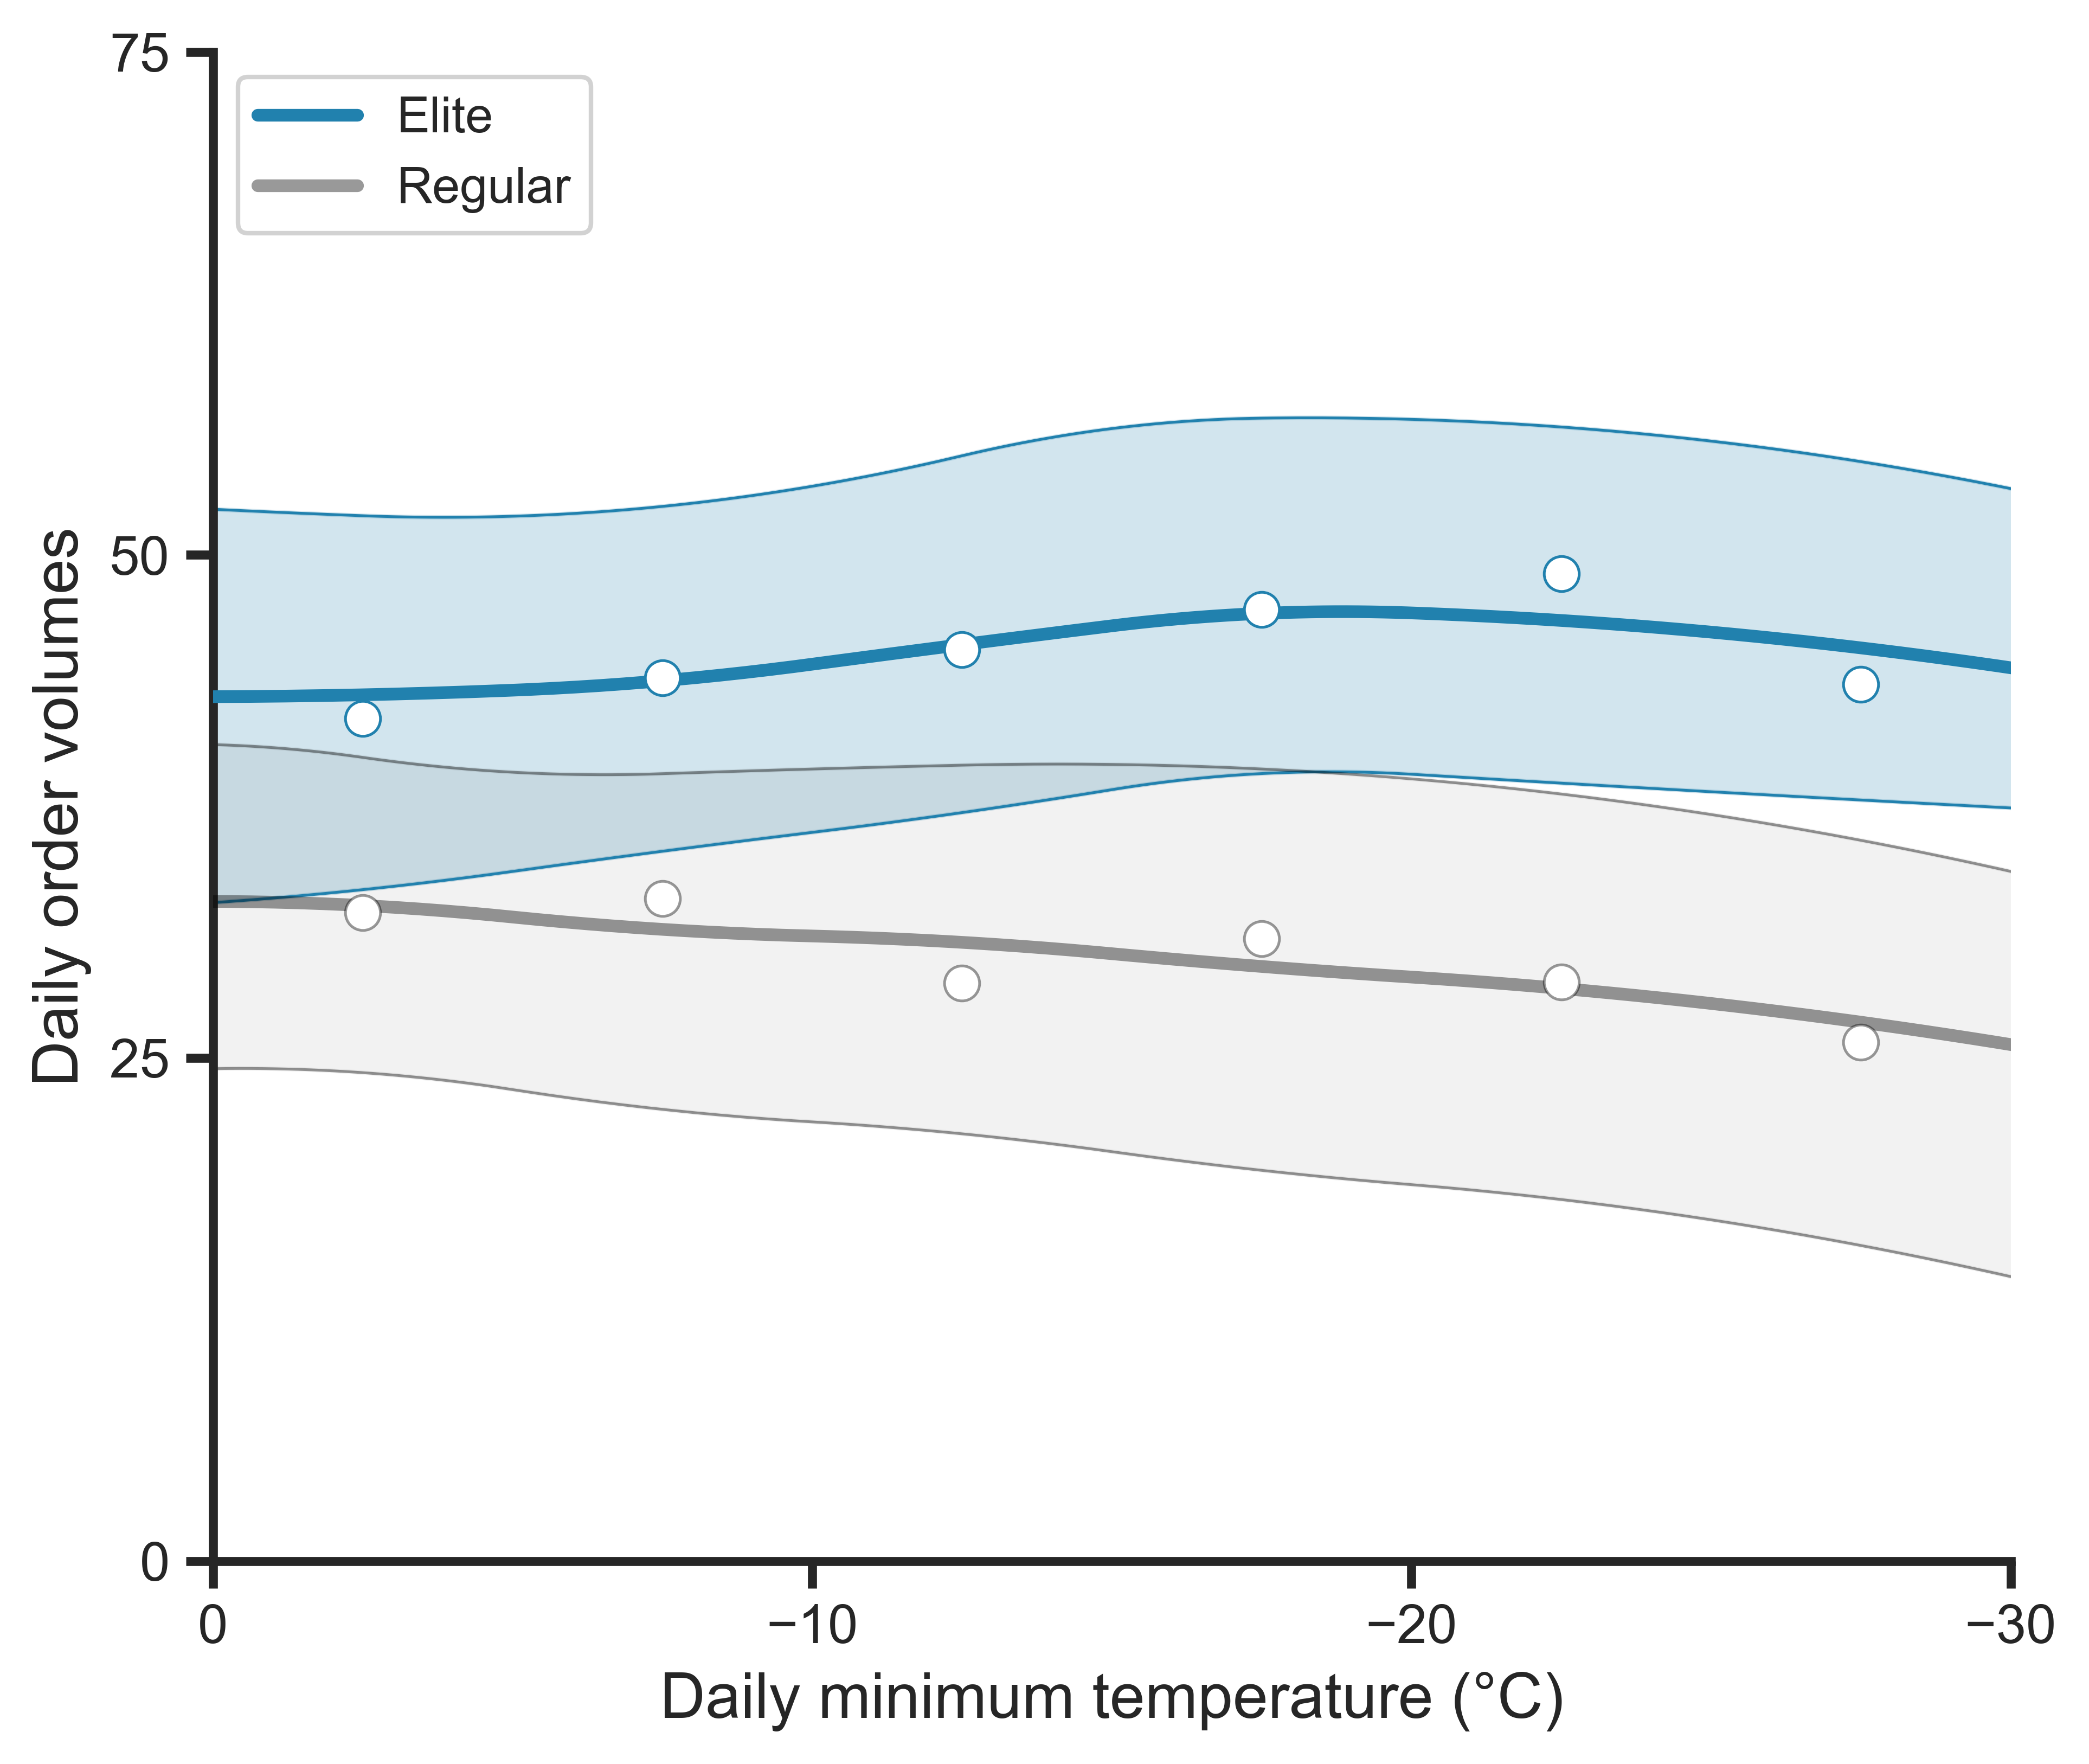

In [5]:
bins_x = np.arange(-35, 6, 5)

fig1d, ax1d = plt.subplots(figsize=(7, 6), dpi=600)
x1, y1_wl, x2, y2_wl = draw_band(ax1d, "Ta_min", "Workload", bins_x, smooth_factor=0.3, ylabel="Workload (hours)")
ax1d.set_xlim(0, -30)
ax1d.set_ylim(0, 60)
ax1d.set_xticks(np.arange(0, -31, -10))
ax1d.set_yticks(np.arange(0, 61, 20))
ax1d.legend(frameon=False, loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Fig1d.tiff", dpi=600, format="tiff", bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

x_ratio, ratio_E = calc_overload_ratio(x1, y1_wl, bins_x, threshold=OVERLOAD_THRESHOLD)
_, ratio_R = calc_overload_ratio(x2, y2_wl, bins_x, threshold=OVERLOAD_THRESHOLD)

fig2d, ax2d = plt.subplots(figsize=(7, 6), dpi=600)
bar_w = 2.0
ax2d.bar(x_ratio + bar_w / 2, ratio_E * 100, width=bar_w, color="#A6C6DF", edgecolor=COLORS["elite_line"], lw=0.6, label="Elite", zorder=3)
ax2d.bar(x_ratio - bar_w / 2, ratio_R * 100, width=bar_w, color="#F2F2F2", edgecolor=COLORS["regular_line"], lw=0.6, label="Regular", zorder=3)
ax2d.axhline(0, color="black", lw=0.5, zorder=6, clip_on=False)
ax2d.spines["bottom"].set_zorder(6)
ax2d.xaxis.set_zorder(6)
ax2d.tick_params(axis="x", zorder=6)
ax2d.set(xlabel="Daily minimum temperature (°C)", ylabel="Overload ratio (%)", xlim=(0, -30), ylim=(0, 60), xticks=np.arange(0, -31, -10), yticks=np.arange(0, 61, 20))
ax2d.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2d.legend(frameon=True, loc="upper left", fontsize=11, facecolor="white", edgecolor="#d0d0d0", framealpha=0.95)
plt.tight_layout(pad=2.0)
plt.savefig(OUTPUT_DIR / "Fig2e.tiff", dpi=600, format="tiff", bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

fig3d, ax3d = plt.subplots(figsize=(7, 6), dpi=600)
draw_band(ax3d, "Ta_min", "On-dutyHour", bins_x, smooth_factor=0.05, ylabel="On-duty time (hours)")
ax3d.set(xlim=(0, -30), ylim=(0, 15), xticks=np.arange(0, -31, -10), yticks=np.arange(0, 16, 5))
ax3d.legend(frameon=True, loc="upper left", fontsize=11, facecolor="white", edgecolor="#d0d0d0", framealpha=0.95)
plt.tight_layout(pad=2.0)
plt.savefig(OUTPUT_DIR / "Fig3d.tiff", dpi=600, format="tiff", bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()

figs7b, axs7b = plt.subplots(figsize=(7, 6), dpi=600)
draw_band(axs7b, "Ta_min", "OrderCount", bins_x, smooth_factor=0.05, ylabel="Daily order volumes")
axs7b.set(xlim=(0, -30), ylim=(0, 75), xticks=np.arange(0, -31, -10), yticks=np.arange(0, 80, 25))
axs7b.legend(frameon=True, loc="upper left", fontsize=11, facecolor="white", edgecolor="#d0d0d0", framealpha=0.95)
plt.tight_layout(pad=2.0)
plt.savefig(SI_DIR / "Figs7b.tiff", dpi=600, format="tiff", bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
plt.show()